СИСТЕМА ТЕСТИРОВАНИЯ АЛГОРИТМОВ С УЧЕТОМ НАПРАВЛЕНИЙ
1. ЗАГРУЗКА ДАННЫХ С НАПРАВЛЕНИЯМИ...
Загрузка реального аудиодатасета...
Найдено 10 аудиофайлов
Загрузка файла: audiodata\1.101.wav
Успешно загружен: audiodata\1.101.wav, направление: 0.0°
Загрузка файла: audiodata\1.102.wav
Успешно загружен: audiodata\1.102.wav, направление: 20.0°
Загрузка файла: audiodata\1.103.wav
Успешно загружен: audiodata\1.103.wav, направление: 40.0°
Загрузка файла: audiodata\1.104.wav
Успешно загружен: audiodata\1.104.wav, направление: 60.0°
Загрузка файла: audiodata\1.105.wav
Успешно загружен: audiodata\1.105.wav, направление: 80.0°
Загрузка файла: audiodata\1.107.wav
Успешно загружен: audiodata\1.107.wav, направление: 100.0°
Загрузка файла: audiodata\1.108.wav
Успешно загружен: audiodata\1.108.wav, направление: 120.0°
Загрузка файла: audiodata\1.109.wav
Успешно загружен: audiodata\1.109.wav, направление: 140.0°
Загрузка файла: audiodata\1.110.wav
Успешно загружен: audiodata\1.110.wav, направление: 160.0°
З

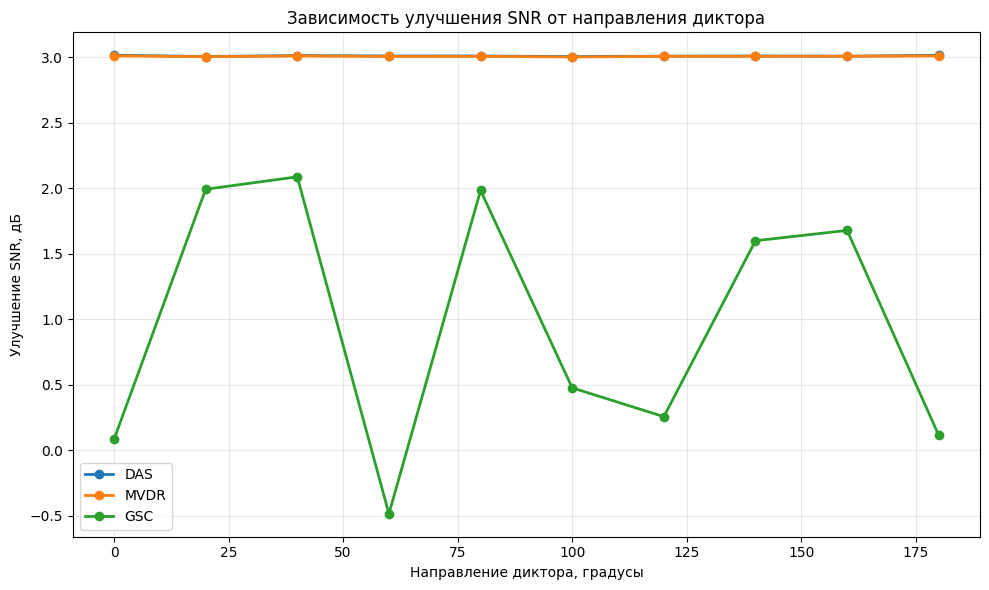

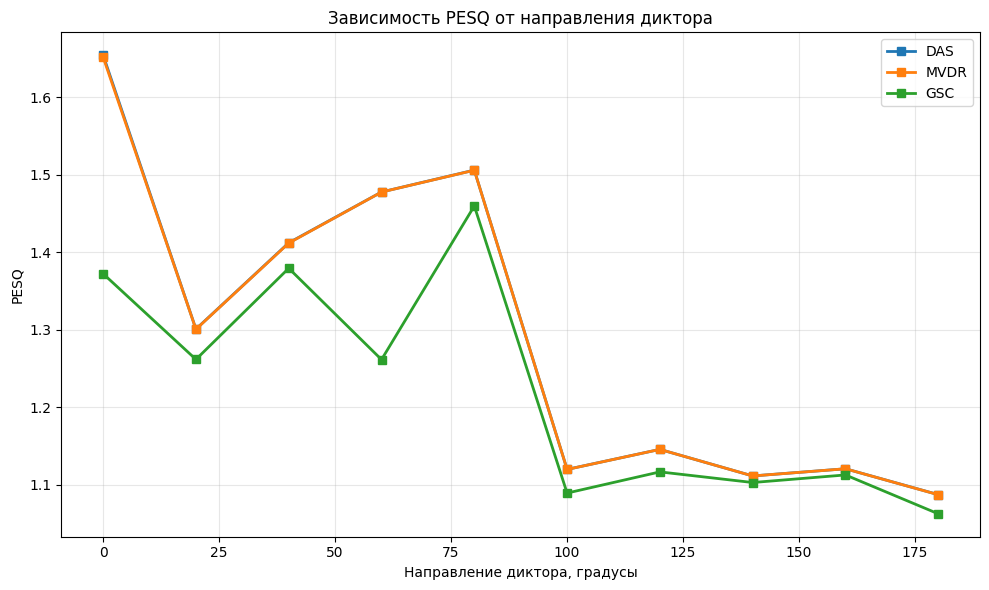

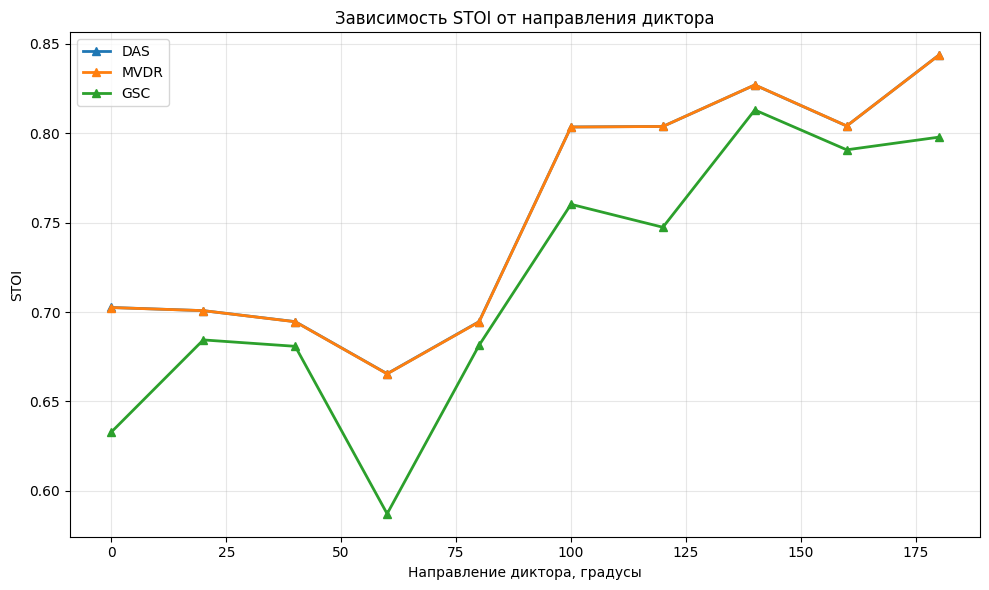

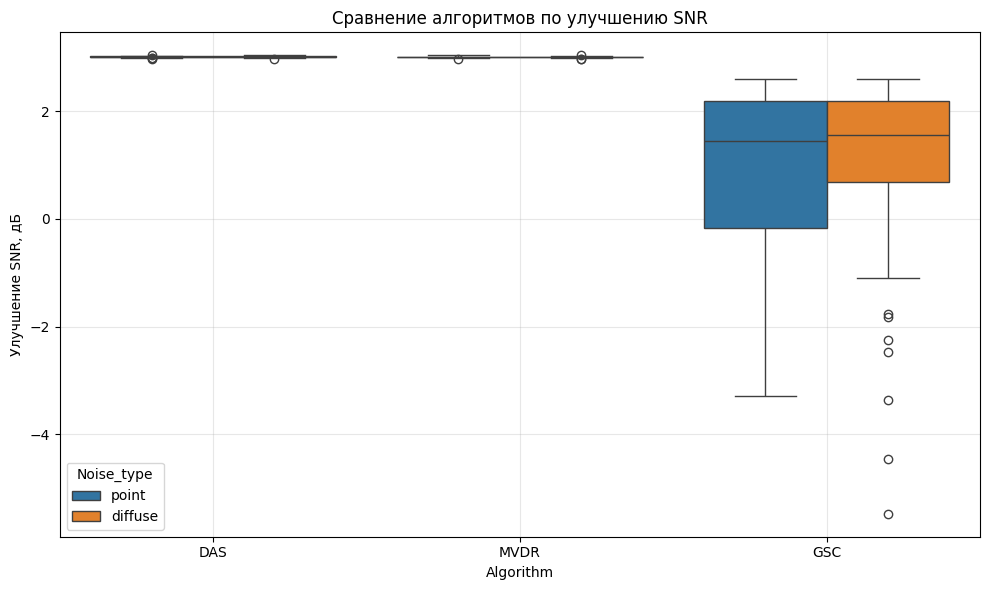

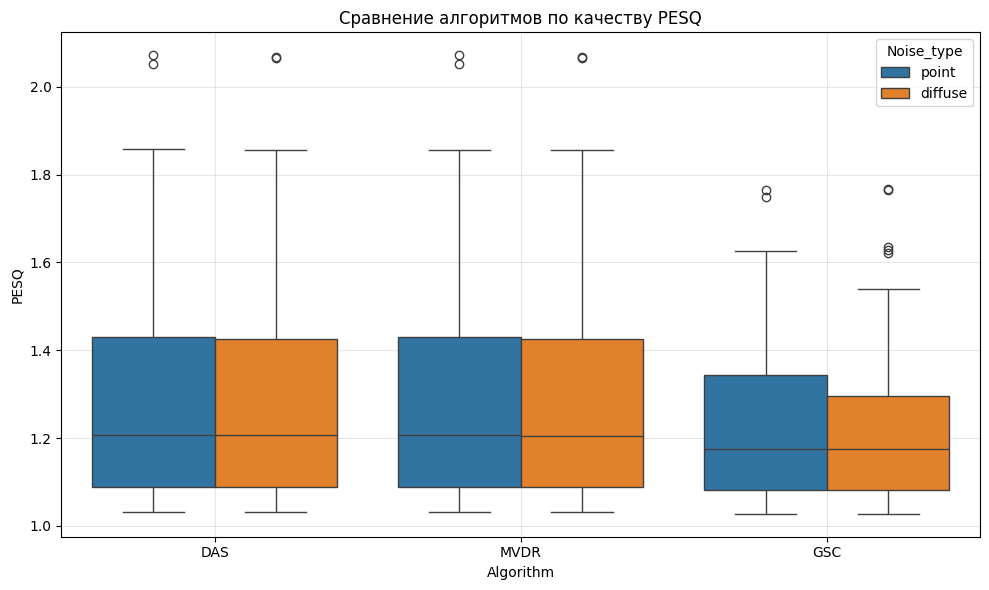

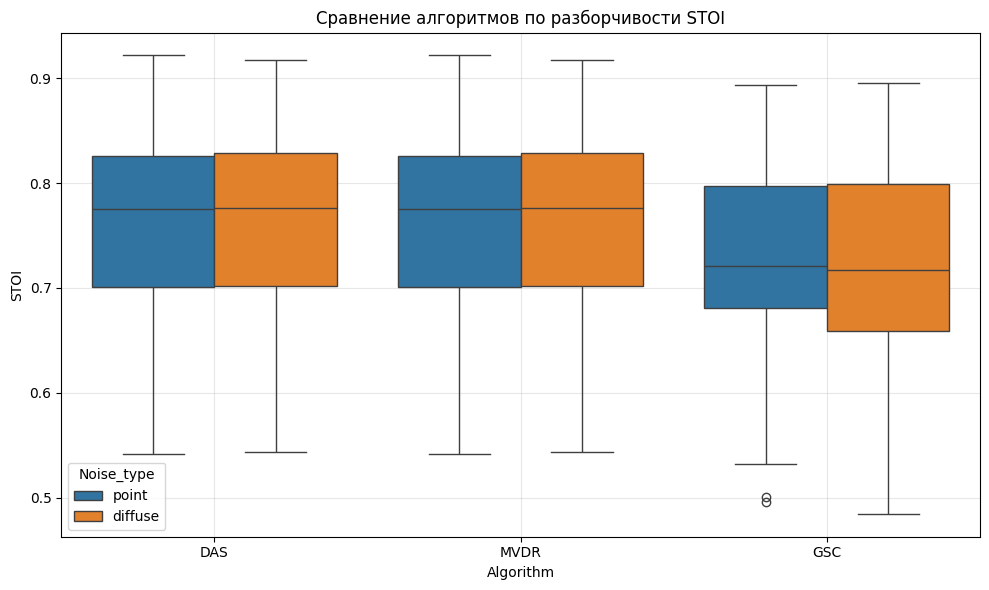

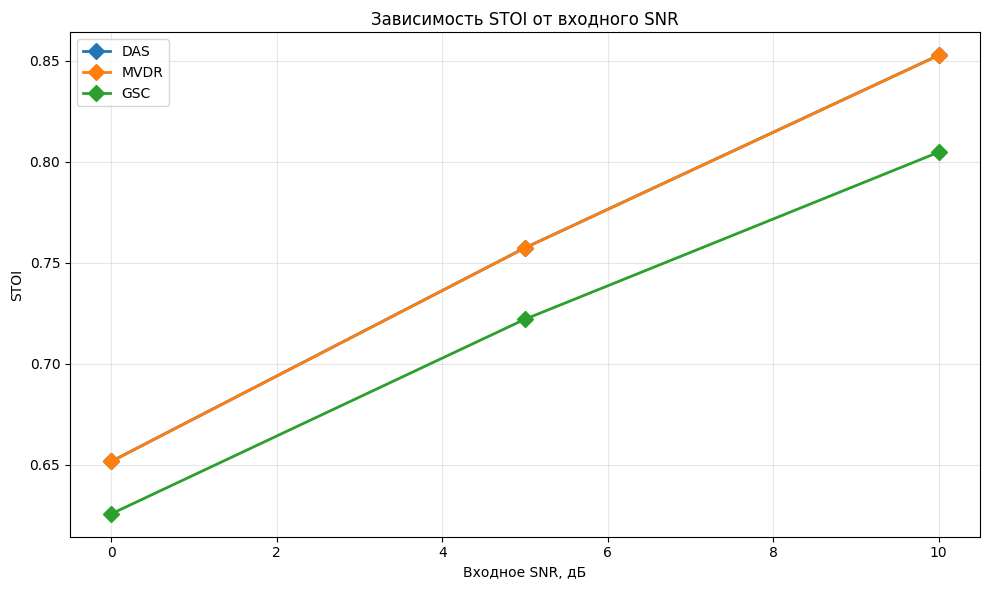

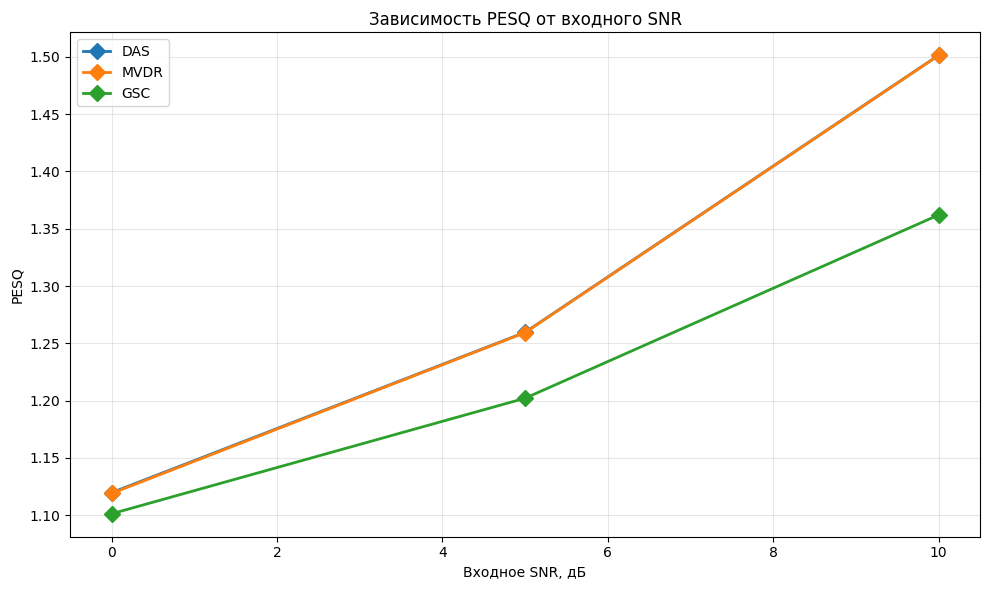

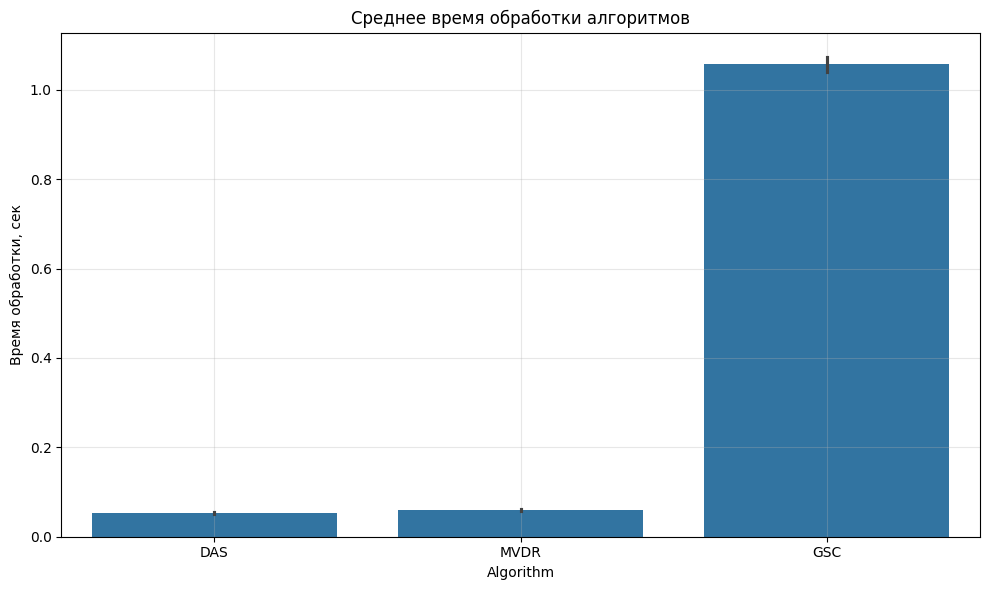

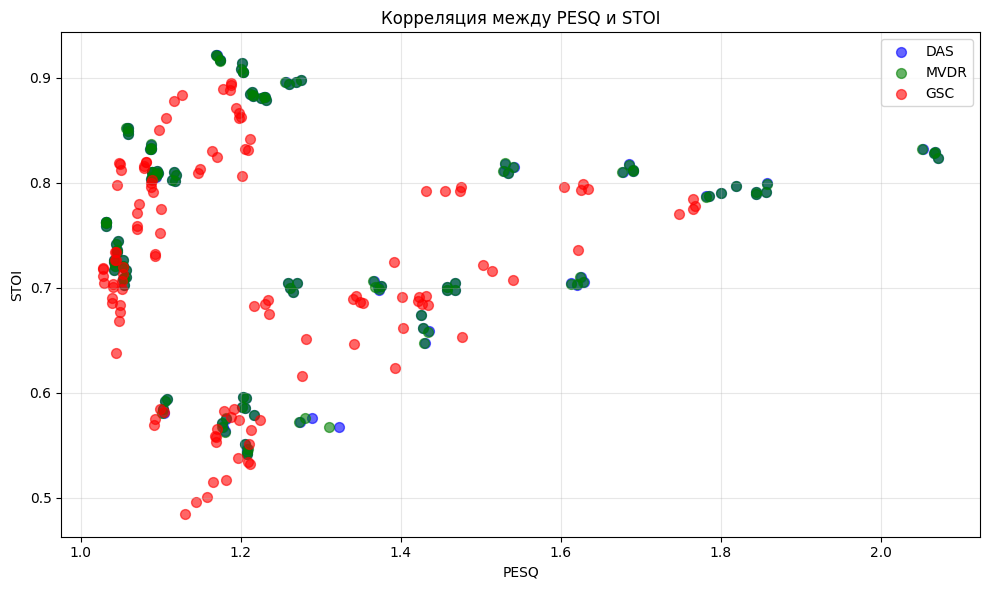

Все графики сохранены в папке 'results_plots'
Результаты сохранены в файл: directional_beamforming_results_20251004_063437.xlsx

ЭКСПЕРИМЕНТ ЗАВЕРШЕН!


In [2]:
# -*- coding: utf-8 -*-
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import signal
from scipy.linalg import eigh
import pandas as pd
import time
from datetime import datetime
import warnings
import soundfile as sf
import os
from pathlib import Path
warnings.filterwarnings('ignore')
from pystoi import stoi
from pesq import pesq

# Проверка доступности аудио метрик
try:
    from pystoi import stoi
    from pesq import pesq
    HAS_AUDIO_METRICS = True
except ImportError:
    HAS_AUDIO_METRICS = False
    print("Предупреждение: pystoi или pesq не установлены. Установите для точных метрик.")

class BeamformingExperiment:
    """
    Класс для экспериментального исследования алгоритмов пространственной фильтрации
    Двухэлементная микрофонная система для выделения речи в зашумленных помещениях
    """
    
    def __init__(self, fs=16000, d=0.15, c=343):
        # Основные параметры системы
        self.fs = fs
        self.d = d
        self.c = c
        self.results = {}
        self.audio_samples = []
    
    def load_real_audio_dataset(self, dataset_path, num_samples=50):
        """
        Загрузка реальных аудиофайлов для экспериментов
        Каждый файл будет использован как отдельный диктор с разными направлениями
        """
        print("Загрузка реального аудиодатасета...")
        
        self.audio_samples = []
        
        # Поиск аудиофайлов в директории
        if not os.path.exists(dataset_path):
            print(f"Директория {dataset_path} не найдена.")
            return []
        
        audio_files = []
        for ext in ['*.wav', '*.mp3', '*.flac']:
            audio_files.extend(Path(dataset_path).glob(ext))
            audio_files.extend(Path(dataset_path).glob(ext.upper()))
        
        audio_files = audio_files[:num_samples]
        
        if not audio_files:
            print(f"Не найдены аудиофайлы в {dataset_path}.")
            return []
        
        print(f"Найдено {len(audio_files)} аудиофайлов")
        
        # Назначаем каждому файлу уникальное направление
        directions = np.linspace(0, 180, len(audio_files))
        
        for i, (file_path, direction) in enumerate(zip(audio_files, directions)):
            try:
                print(f"Загрузка файла: {file_path}")
                audio_data, fs_file = sf.read(str(file_path))
                
                # Приведение к моно
                if len(audio_data.shape) > 1:
                    audio_data = np.mean(audio_data, axis=1)
                
                # Ресемплинг при необходимости
                if fs_file != self.fs:
                    num_samples_target = int(len(audio_data) * self.fs / fs_file)
                    audio_data = signal.resample(audio_data, num_samples_target)
                
                # Обрезка длинных файлов
                if len(audio_data) > self.fs * 10:
                    audio_data = audio_data[:self.fs * 10]
                
                # Нормализация
                if np.max(np.abs(audio_data)) > 0:
                    audio_data = audio_data / np.max(np.abs(audio_data)) * 0.8
                
                # Сохраняем информацию о направлении
                self.audio_samples.append({
                    'audio': audio_data,
                    'duration': len(audio_data) / self.fs,
                    'sample_id': i,
                    'source': str(file_path),
                    'true_direction': direction,  # Истинное направление диктора
                    'direction_deg': round(direction, 1)  # Округленное значение для отчетов
                })
                
                print(f"Успешно загружен: {file_path}, направление: {direction:.1f}°")
                
            except Exception as e:
                print(f"Ошибка загрузки {file_path}: {e}")
                continue
        
        print(f"Загружено {len(self.audio_samples)} реальных аудиозаписей с направлениями")
        return self.audio_samples

    def create_test_dataset(self, num_samples=50):
        """
        Создание синтезированных речеподобных сигналов с направлениями
        """
        print("Создание тестового датасета...")
        
        self.audio_samples = []
        
        # Создаем направления для каждого сэмпла
        directions = np.linspace(0, 180, num_samples)
        
        for i in range(num_samples):
            duration = 3.0 + 2.0 * np.random.random()
            t = np.linspace(0, duration, int(self.fs * duration))
            
            speech_signal = self._generate_speech_signal(t)
            
            if np.max(np.abs(speech_signal)) > 0:
                speech_signal = speech_signal / np.max(np.abs(speech_signal)) * 0.8
            
            self.audio_samples.append({
                'audio': speech_signal,
                'duration': duration,
                'sample_id': i,
                'source': 'synthetic',
                'true_direction': directions[i],
                'direction_deg': round(directions[i], 1)
            })
        
        print(f"Создано {len(self.audio_samples)} тестовых образцов с направлениями")
        return self.audio_samples
    
    def _generate_speech_signal(self, t):
        """
        Генерация речеподобного сигнала для тестирования
        """
        pitch_freq = 100 + 30 * np.random.random()
        syllable_rate = 3 + 2 * np.random.random()
        
        base_signal = 0.5 * np.sin(2 * np.pi * pitch_freq * t)
        
        formants = [
            (300 + 50 * np.random.random(), 0.3),
            (800 + 100 * np.random.random(), 0.2),
            (1200 + 150 * np.random.random(), 0.15),
            (2500 + 200 * np.random.random(), 0.1),
        ]
        
        for freq, amp in formants:
            formant_signal = amp * np.sin(2 * np.pi * freq * t)
            formant_signal *= (0.9 + 0.2 * np.sin(2 * np.pi * 0.3 * t))
            base_signal += formant_signal
        
        amplitude_envelope = 0.7 + 0.3 * np.sin(2 * np.pi * syllable_rate * t)
        base_signal *= amplitude_envelope
        
        # Добавляем паузы как в реальной речи
        for _ in range(3):
            pause_start = np.random.randint(0, len(t) - int(0.2 * self.fs))
            pause_end = pause_start + int(0.1 * self.fs)
            if pause_end < len(base_signal):
                base_signal[pause_start:pause_end] *= 0.1
        
        return base_signal

    def simulate_microphone_signals(self, clean_signal, true_direction=0, 
                                  interference_angle=60, snr_db=5, noise_type='point'):
        """
        Имитация сигналов на двухэлементной микрофонной системе
        с учетом истинного направления диктора
        """
        signal_length = len(clean_signal)
        
        # Генерация шумов в зависимости от типа
        if noise_type == 'point':
            # Точечная помеха
            base_noise = np.random.randn(signal_length)
            noise1 = 0.7 * base_noise + 0.3 * np.random.randn(signal_length)
            noise2 = 0.7 * base_noise + 0.3 * np.random.randn(signal_length)
        else:
            # Диффузный шум
            noise1 = np.random.randn(signal_length)
            noise2 = np.random.randn(signal_length)
        
        noise_signals = [noise1, noise2]
        
        # Расчет задержек для истинного направления диктора
        target_delays = self.calculate_delays(true_direction)
        interference_delays = self.calculate_delays(interference_angle)
        
        # Формирование сигналов на микрофонах
        mic_signals = []
        for i in range(2):
            # Целевой сигнал с задержкой согласно истинному направлению
            target_delayed = self.apply_fractional_delay(clean_signal, target_delays[i])
            
            # Шум с задержкой
            noise_delayed = self.apply_fractional_delay(noise_signals[i], interference_delays[i])
            
            # Нормализация мощности шума для заданного SNR
            target_power = np.mean(target_delayed**2) + 1e-10
            noise_power = np.mean(noise_delayed**2) + 1e-10
            
            desired_noise_power = target_power / (10**(snr_db/10))
            scale_factor = np.sqrt(desired_noise_power / noise_power)
            noise_delayed = noise_delayed * scale_factor
            
            mic_signal = target_delayed + noise_delayed
            mic_signals.append(mic_signal)
        
        return {
            'mic_signals': mic_signals,
            'target_delays': target_delays,
            'true_direction': true_direction,
            'clean_signal': clean_signal,
            'noise_type': noise_type
        }

    def robust_mvdr_beamformer(self, mic_signals, target_delays, noise_frame_start=0.1, diagonal_loading=0.05):
        """
        Реализация алгоритма MVDR с улучшенной устойчивостью
        """
        num_mics = len(mic_signals)
        signal_length = len(mic_signals[0])
        
        # Выравнивание сигналов по целевому направлению
        aligned_signals = []
        for i, sig in enumerate(mic_signals):
            aligned = self.apply_fractional_delay(sig, -target_delays[i])
            aligned_signals.append(aligned)
        
        aligned_signals = np.array(aligned_signals)
        
        # Разделение на шумовые и речевые сегменты
        noise_samples = int(noise_frame_start * self.fs)
        
        if noise_samples > 100 and signal_length - noise_samples > 100:
            noise_segment = aligned_signals[:, :noise_samples]
            signal_segment = aligned_signals[:, noise_samples:]
            
            # Оценка ковариационных матриц
            noise_cov = np.cov(noise_segment) + diagonal_loading * np.eye(num_mics) * np.trace(np.cov(noise_segment))
            signal_cov = np.cov(signal_segment) + 0.01 * np.eye(num_mics) * np.trace(np.cov(signal_segment))
            
            steering_vector = np.ones(num_mics)
            steering_vector = steering_vector[:, np.newaxis]
            
            try:
                # Классическая формула MVDR
                noise_cov_inv = np.linalg.inv(noise_cov)
                numerator = noise_cov_inv @ steering_vector
                denominator = steering_vector.conj().T @ numerator
                weights = numerator / denominator
                
                output_signal = np.zeros(signal_length)
                for i in range(num_mics):
                    output_signal += weights[i, 0].real * aligned_signals[i]
                    
                return output_signal
                
            except np.linalg.LinAlgError:
                print("Ошибка матричного разложения в MVDR, используется DAS")
        
        # Резервный вариант
        return self.das_beamformer(mic_signals, target_delays)

    def improved_gsc_beamformer(self, mic_signals, target_delays, mu=0.001, filter_length=256, adaptation_ratio=0.3):
        """
        Реализация алгоритма GSC с защитой от утечки целевого сигнала
        """
        signal_length = len(mic_signals[0])
        if signal_length < filter_length * 3:
            return self.das_beamformer(mic_signals, target_delays)
        
        # Фиксированный формирователь луча
        fixed_beam_output = self.das_beamformer(mic_signals, target_delays)
        
        # Блокирующая матрица
        aligned_signals = []
        for i, sig in enumerate(mic_signals):
            aligned = self.apply_fractional_delay(sig, -target_delays[i])
            aligned_signals.append(aligned)
        
        aligned_signals = np.array(aligned_signals)
        blocked_signal = aligned_signals[0] - aligned_signals[1]
        
        # Нормализация блокированного сигнала
        blocked_power = np.mean(blocked_signal**2) + 1e-10
        blocked_signal = blocked_signal / np.sqrt(blocked_power)
        
        # Адаптивный фильтр
        anc_filter = np.zeros(filter_length)
        output_signal = np.zeros_like(fixed_beam_output)
        
        output_signal[:filter_length] = fixed_beam_output[:filter_length]
        
        adaptation_start = filter_length
        adaptation_end = min(len(fixed_beam_output), 
                           adaptation_start + int(len(fixed_beam_output) * adaptation_ratio))
        
        # Адаптация фильтра
        for n in range(adaptation_start, adaptation_end):
            x_blocked = blocked_signal[n - filter_length: n][::-1]
            
            power = np.mean(x_blocked**2) + 1e-10
            normalized_mu = mu / power
            
            y_anc = np.dot(anc_filter, x_blocked)
            error = fixed_beam_output[n] - y_anc
            
            step_size = normalized_mu * error
            step_size = np.clip(step_size, -0.05, 0.05)
            
            anc_filter += step_size * x_blocked
            anc_filter *= 0.999  # Регуляризация
            
            output_signal[n] = error
        
        # Применение обученного фильтра
        for n in range(adaptation_end, len(fixed_beam_output)):
            x_blocked = blocked_signal[n - filter_length: n][::-1]
            y_anc = np.dot(anc_filter, x_blocked)
            output_signal[n] = fixed_beam_output[n] - y_anc
        
        return output_signal

    def das_beamformer(self, mic_signals, delays):
        """
        Реализация алгоритма DAS в частотной области
        """
        aligned_signals = []
        for i, sig in enumerate(mic_signals):
            aligned = self.apply_fractional_delay(sig, -delays[i])
            aligned_signals.append(aligned)
        return np.mean(aligned_signals, axis=0)
    
    def apply_fractional_delay(self, signal, delay_samples):
        """
        Применение дробной задержки в частотной области
        """
        N = len(signal)
        if N == 0:
            return signal
            
        frequencies = np.fft.fftfreq(N, 1/self.fs)
        spectrum = np.fft.fft(signal)
        phase_shift = np.exp(-1j * 2 * np.pi * frequencies * delay_samples)
        delayed_spectrum = spectrum * phase_shift
        
        return np.real(np.fft.ifft(delayed_spectrum))
    
    def calculate_delays(self, angle_deg):
        """
        Расчет временных задержек между микрофонами для заданного угла
        """
        angle_rad = np.deg2rad(angle_deg)
        delays = np.zeros(2)
        for i in range(2):
            delays[i] = (i * self.d * np.cos(angle_rad)) / self.c * self.fs
        return delays
    
    def calculate_comprehensive_metrics(self, clean_signal, processed_signal, noisy_signal=None):
        """
        Расчет метрик качества обработки сигнала
        """
        min_len = min(len(clean_signal), len(processed_signal))
        if min_len < 256:
            base_metrics = {'SNR_output': 0, 'MSE': 1, 'PSNR': 0, 'PESQ': 1.0, 'STOI': 0}
            if noisy_signal is not None:
                base_metrics['SNR_improvement'] = 0
            return base_metrics
        
        clean = clean_signal[:min_len]
        processed = processed_signal[:min_len]
        
        metrics = {}
        
        # Базовые метрики
        noise_output = clean - processed
        noise_power = np.mean(noise_output**2) + 1e-10
        signal_power = np.mean(clean**2) + 1e-10
        metrics['SNR_output'] = 10 * np.log10(signal_power / noise_power)
        
        # Улучшение SNR
        if noisy_signal is not None and len(noisy_signal) >= min_len:
            noisy = noisy_signal[:min_len]
            noise_input = clean - noisy
            noise_input_power = np.mean(noise_input**2) + 1e-10
            snr_input = 10 * np.log10(signal_power / noise_input_power)
            metrics['SNR_improvement'] = metrics['SNR_output'] - snr_input
        else:
            metrics['SNR_improvement'] = metrics['SNR_output']
        
        # MSE и PSNR
        metrics['MSE'] = np.mean((clean - processed)**2)
        max_signal = np.max(np.abs(clean)) + 1e-10
        metrics['PSNR'] = 20 * np.log10(max_signal / np.sqrt(metrics['MSE'] + 1e-10))
        
        # Профессиональные метрики качества речи
        if HAS_AUDIO_METRICS and min_len > self.fs * 0.5:
            try:
                pesq_length = (min_len // self.fs) * self.fs
                if pesq_length > self.fs:
                    metrics['PESQ'] = pesq(self.fs, clean[:pesq_length], processed[:pesq_length], 'wb')
                else:
                    metrics['PESQ'] = 1.0
            except Exception as e:
                print(f"Ошибка PESQ: {e}")
                metrics['PESQ'] = 1.0
            
            try:
                metrics['STOI'] = stoi(clean, processed, self.fs, extended=False)
            except Exception as e:
                print(f"Ошибка STOI: {e}")
                metrics['STOI'] = 0
        else:
            metrics['PESQ'] = 1.0
            metrics['STOI'] = 0
        
        return metrics
    
    def run_directional_experiment(self, num_samples=30, snr_levels=[0, 5, 10], 
                                 noise_types=['point', 'diffuse'], interference_angles=[45, 90]):
        """
        Проведение эксперимента с учетом направлений дикторов
        """
        print("=== ЭКСПЕРИМЕНТ С УЧЕТОМ НАПРАВЛЕНИЙ ДИКТОРОВ ===")
        
        if len(self.audio_samples) < num_samples:
            remaining_samples = num_samples - len(self.audio_samples)
            self.create_test_dataset(remaining_samples)
        
        results = []
        
        for sample_idx in range(min(num_samples, len(self.audio_samples))):
            sample = self.audio_samples[sample_idx]
            print(f"Обработка sample {sample_idx + 1}/{min(num_samples, len(self.audio_samples))}, "
                  f"направление: {sample['direction_deg']}°")
            
            try:
                clean_audio = sample['audio']
                true_direction = sample['true_direction']
                
                for snr in snr_levels:
                    for noise_type in noise_types:
                        for interference_angle in interference_angles:
                            # Имитация микрофонных сигналов с истинным направлением
                            simulated_data = self.simulate_microphone_signals(
                                clean_audio, 
                                true_direction=true_direction,
                                interference_angle=interference_angle, 
                                noise_type=noise_type, 
                                snr_db=snr
                            )
                            
                            # Тестируемые алгоритмы
                            algorithms = {
                                'DAS': self.das_beamformer,
                                'MVDR': self.robust_mvdr_beamformer,
                                'GSC': self.improved_gsc_beamformer
                            }
                            
                            for algo_name, algo_func in algorithms.items():
                                start_time = time.time()
                                
                                try:
                                    # Обработка сигнала с использованием истинного направления
                                    processed_signal = algo_func(
                                        simulated_data['mic_signals'].copy(), 
                                        simulated_data['target_delays']
                                    )
                                    
                                    processing_time = time.time() - start_time
                                    
                                    # Расчет метрик
                                    audio_metrics = self.calculate_comprehensive_metrics(
                                        simulated_data['clean_signal'],
                                        processed_signal,
                                        simulated_data['mic_signals'][0]
                                    )
                                    
                                    results.append({
                                        'sample_id': sample_idx,
                                        'true_direction': sample['direction_deg'],
                                        'SNR_input': snr,
                                        'Noise_type': noise_type,
                                        'Interference_angle': interference_angle,
                                        'Algorithm': algo_name,
                                        'SNR_output': audio_metrics.get('SNR_output', 0),
                                        'SNR_improvement': audio_metrics.get('SNR_improvement', 0),
                                        'MSE': audio_metrics.get('MSE', 0),
                                        'PSNR': audio_metrics.get('PSNR', 0),
                                        'PESQ': audio_metrics.get('PESQ', 1.0),
                                        'STOI': audio_metrics.get('STOI', 0),
                                        'Processing_time': processing_time
                                    })
                                    
                                except Exception as algo_error:
                                    print(f"Ошибка в алгоритме {algo_name}: {algo_error}")
                                    continue
                                
            except Exception as e:
                print(f"Ошибка при обработке sample {sample_idx}: {str(e)}")
                continue
        
        if results:
            self.results['directional_experiment'] = pd.DataFrame(results)
        else:
            print("Нет результатов для анализа")
            self.results['directional_experiment'] = pd.DataFrame()
            
        return self.results['directional_experiment']
    
    def analyze_directional_results(self):
        """
        Расширенный анализ результатов эксперимента с направлениями
        """
        if 'directional_experiment' not in self.results or self.results['directional_experiment'].empty:
            print("Нет данных для анализа")
            return None, None
        
        data = self.results['directional_experiment']
        
        print("\n=== ДЕТАЛЬНЫЙ АНАЛИЗ РЕЗУЛЬТАТОВ С УЧЕТОМ НАПРАВЛЕНИЙ ===")
        
        # Анализ по алгоритмам и направлениям
        direction_summary = data.groupby(['Algorithm', 'true_direction']).agg({
            'SNR_improvement': ['mean', 'std'],
            'PESQ': ['mean', 'std'],
            'STOI': ['mean', 'std']
        }).round(4)
        
        print("Эффективность алгоритмов по направлениям:")
        print(direction_summary)
        
        # Сравнение эффективности при разных условиях
        condition_summary = data.groupby(['Algorithm', 'Noise_type', 'SNR_input']).agg({
            'SNR_improvement': 'mean',
            'PESQ': 'mean',
            'STOI': 'mean',
            'Processing_time': 'mean'
        }).round(4)
        
        print("\nЭффективность по типам шума и SNR:")
        print(condition_summary)
        
        # Анализ STOI отдельно
        stoi_summary = data.groupby(['Algorithm', 'Noise_type']).agg({
            'STOI': ['mean', 'std', 'min', 'max']
        }).round(4)
        
        print("\nДетальная статистика STOI:")
        print(stoi_summary)
        
        # Построение отдельных графиков
        self.plot_individual_results(data)
        
        return direction_summary, condition_summary

    def plot_individual_results(self, data):
        """
        Расширенная визуализация результатов эксперимента с направлениями
        Включает все ключевые метрики: SNR, PESQ и STOI
        """
        if data.empty:
                print("Нет данных для визуализации")
                return
            
        # 1. График: Улучшение SNR по направлениям
        plt.figure(figsize=(10, 6))
        for algo in data['Algorithm'].unique():
            algo_data = data[data['Algorithm'] == algo]
            if not algo_data.empty:
                direction_means = algo_data.groupby('true_direction')['SNR_improvement'].mean()
                plt.plot(direction_means.index, direction_means.values, 
                        marker='o', label=algo, linewidth=2, markersize=6)
        
        plt.title('Зависимость улучшения SNR от направления диктора')
        plt.xlabel('Направление диктора, градусы')
        plt.ylabel('Улучшение SNR, дБ')
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.savefig('results_plots/SNR_improvement_vs_direction.png', dpi=300, bbox_inches='tight')
        plt.show()
        
        # 2. График: PESQ по направлениям
        plt.figure(figsize=(10, 6))
        for algo in data['Algorithm'].unique():
            algo_data = data[data['Algorithm'] == algo]
            if not algo_data.empty:
                direction_means = algo_data.groupby('true_direction')['PESQ'].mean()
                plt.plot(direction_means.index, direction_means.values, 
                        marker='s', label=algo, linewidth=2, markersize=6)
        
        plt.title('Зависимость PESQ от направления диктора')
        plt.xlabel('Направление диктора, градусы')
        plt.ylabel('PESQ')
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.savefig('results_plots/PESQ_vs_direction.png', dpi=300, bbox_inches='tight')
        plt.show()
        
        # 3. График: STOI по направлениям
        plt.figure(figsize=(10, 6))
        for algo in data['Algorithm'].unique():
            algo_data = data[data['Algorithm'] == algo]
            if not algo_data.empty:
                direction_means = algo_data.groupby('true_direction')['STOI'].mean()
                plt.plot(direction_means.index, direction_means.values, 
                        marker='^', label=algo, linewidth=2, markersize=6)
        
        plt.title('Зависимость STOI от направления диктора')
        plt.xlabel('Направление диктора, градусы')
        plt.ylabel('STOI')
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.savefig('results_plots/STOI_vs_direction.png', dpi=300, bbox_inches='tight')
        plt.show()
        
        # 4. График: Сравнение улучшения SNR по алгоритмам и типам шума
        plt.figure(figsize=(10, 6))
        sns.boxplot(data=data, x='Algorithm', y='SNR_improvement', hue='Noise_type')
        plt.title('Сравнение алгоритмов по улучшению SNR')
        plt.ylabel('Улучшение SNR, дБ')
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.savefig('results_plots/SNR_improvement_comparison.png', dpi=300, bbox_inches='tight')
        plt.show()
        
        # 5. График: Сравнение PESQ по алгоритмам и типам шума
        plt.figure(figsize=(10, 6))
        sns.boxplot(data=data, x='Algorithm', y='PESQ', hue='Noise_type')
        plt.title('Сравнение алгоритмов по качеству PESQ')
        plt.ylabel('PESQ')
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.savefig('results_plots/PESQ_comparison.png', dpi=300, bbox_inches='tight')
        plt.show()
        
        # 6. График: Сравнение STOI по алгоритмам и типам шума
        plt.figure(figsize=(10, 6))
        sns.boxplot(data=data, x='Algorithm', y='STOI', hue='Noise_type')
        plt.title('Сравнение алгоритмов по разборчивости STOI')
        plt.ylabel('STOI')
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.savefig('results_plots/STOI_comparison.png', dpi=300, bbox_inches='tight')
        plt.show()
        
        # 7. График: Зависимость STOI от входного SNR
        plt.figure(figsize=(10, 6))
        for algo in data['Algorithm'].unique():
            algo_data = data[data['Algorithm'] == algo]
            if not algo_data.empty:
                snr_means = algo_data.groupby('SNR_input')['STOI'].mean()
                plt.plot(snr_means.index, snr_means.values, marker='D', 
                        label=algo, linewidth=2, markersize=8)
        
        plt.title('Зависимость STOI от входного SNR')
        plt.xlabel('Входное SNR, дБ')
        plt.ylabel('STOI')
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.savefig('results_plots/STOI_vs_SNR_input.png', dpi=300, bbox_inches='tight')
        plt.show()
        
        # 8. График: Зависимость PESQ от входного SNR
        plt.figure(figsize=(10, 6))
        for algo in data['Algorithm'].unique():
            algo_data = data[data['Algorithm'] == algo]
            if not algo_data.empty:
                snr_means = algo_data.groupby('SNR_input')['PESQ'].mean()
                plt.plot(snr_means.index, snr_means.values, marker='D', 
                        label=algo, linewidth=2, markersize=8)
        
        plt.title('Зависимость PESQ от входного SNR')
        plt.xlabel('Входное SNR, дБ')
        plt.ylabel('PESQ')
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.savefig('results_plots/PESQ_vs_SNR_input.png', dpi=300, bbox_inches='tight')
        plt.show()
        
        # 9. График: Время обработки алгоритмов
        plt.figure(figsize=(10, 6))
        sns.barplot(data=data, x='Algorithm', y='Processing_time')
        plt.title('Среднее время обработки алгоритмов')
        plt.ylabel('Время обработки, сек')
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.savefig('results_plots/processing_time.png', dpi=300, bbox_inches='tight')
        plt.show()
        
        # 10. График: Корреляция PESQ и STOI
        plt.figure(figsize=(10, 6))
        colors = {'DAS': 'blue', 'MVDR': 'green', 'GSC': 'red'}
        
        for algo in data['Algorithm'].unique():
            algo_data = data[data['Algorithm'] == algo]
            plt.scatter(algo_data['PESQ'], algo_data['STOI'], 
                    c=colors.get(algo, 'gray'), label=algo, alpha=0.6, s=50)
        
        plt.xlabel('PESQ')
        plt.ylabel('STOI')
        plt.title('Корреляция между PESQ и STOI')
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.savefig('results_plots/PESQ_vs_STOI_correlation.png', dpi=300, bbox_inches='tight')
        plt.show()
        
        print("Все графики сохранены в папке 'results_plots'")
    

# ЗАПУСК ЭКСПЕРИМЕНТА
if __name__ == "__main__":
    print("СИСТЕМА ТЕСТИРОВАНИЯ АЛГОРИТМОВ С УЧЕТОМ НАПРАВЛЕНИЙ")
    print("=" * 60)
    
    # Инициализация эксперимента
    experiment = BeamformingExperiment(fs=16000, d=0.15)
    
    print("1. ЗАГРУЗКА ДАННЫХ С НАПРАВЛЕНИЯМИ...")
    
    # Загружаем реальные данные с направлениями
    experiment.load_real_audio_dataset('audiodata', num_samples=10)
    
    # Если реальные данные не загрузились, создаем синтезированные
    if len(experiment.audio_samples) == 0:
        print("Реальные данные не загружены, создаем синтезированные...")
        experiment.create_test_dataset(10)
    
    print("2. ЗАПУСК ЭКСПЕРИМЕНТА С НАПРАВЛЕНИЯМИ...")
    results = experiment.run_directional_experiment(
        num_samples=min(10, len(experiment.audio_samples)),
        snr_levels=[0, 5, 10],
        noise_types=['point', 'diffuse'],
        interference_angles=[45, 90]
    )
    
    print("3. АНАЛИЗ РЕЗУЛЬТАТОВ...")
    direction_summary, condition_summary = experiment.analyze_directional_results()
    
    # Сохранение результатов
    if not results.empty:
        timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
        filename = f'directional_beamforming_results_{timestamp}.xlsx'
        
        with pd.ExcelWriter(filename, engine='openpyxl') as writer:
            results.to_excel(writer, sheet_name='raw_results', index=False)
            if direction_summary is not None:
                direction_summary.to_excel(writer, sheet_name='direction_summary')
            if condition_summary is not None:
                condition_summary.to_excel(writer, sheet_name='condition_summary')
        
        print(f"Результаты сохранены в файл: {filename}")
    
    print("\nЭКСПЕРИМЕНТ ЗАВЕРШЕН!")